In [1]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl

import seaborn as sns

# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itertools import product


# With the ic() method you can print something that is between the brackets and automatically also print its name
from icecream import ic


In [2]:
with open('../Data/data/dc-scoped-df.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)

df_70pcnt_scoped = dc_scoped_df['df_70pcnt_scoped']
df_orig = dc_scoped_df['df_pd_pandas']
df_50pcnt_scoped = dc_scoped_df['df_50pcnt_scoped']
df_top_10  = dc_scoped_df['df_top_10']


## descriptive analytics

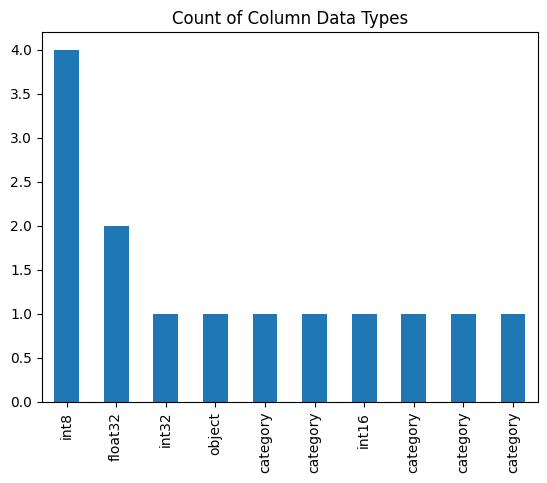

In [3]:
# print(df_orig.describe(include=['object']))
# print(df_orig.describe(include=['category']))
# print(df_orig.isnull().sum())
# print(df_orig.duplicated().sum())
# print(df_orig.nunique())
# print(df_orig.columns.tolist())
df_orig.dtypes.value_counts().plot(kind='bar', title='Count of Column Data Types')
plt.show()



## Find store-item combinations that have no missing on promotion data

df_orig['month'] = df_orig['month'].astype(str)
df_orig['date'] = pd.to_datetime(df_orig['month']) + pd.to_timedelta(df_orig['day'] - 1, unit='d')

# 1. Identify the First and Last Dates in the Dataset
first_date = df_orig['date'].min()
last_date = df_orig['date'].max()
print("First date:", first_date)
print("Last date:", last_date)

# Get the number of unique dates for each (store_nbr, item_nbr) combination
date_counts = (df_orig.groupby(['store_nbr', 'item_nbr'])['date']
    .nunique()
    .reset_index(name='num_dates'))

# Calculate the expected number of days
expected_days = (last_date - first_date).days + 1

# Filter for combinations with all dates
full_coverage = date_counts[date_counts['num_dates'] == expected_days]

# Merge back to original to check for missing onpromotion values
merged = df_orig.merge(full_coverage[['store_nbr', 'item_nbr']], on=['store_nbr', 'item_nbr'])

# For each combination, check if there are any missing onpromotion values
def has_no_missing_onpromotion(subdf):
    return subdf['onpromotion'].isna().sum() == 0

result = (
    merged.groupby(['store_nbr', 'item_nbr'])
    .filter(has_no_missing_onpromotion)
    .drop_duplicates(subset=['store_nbr', 'item_nbr'])
    [['store_nbr', 'item_nbr']]
)

print("Combinations with full coverage and no missing onpromotion:")
print(result)


## Group by Store and make a plot showing contribution to total sales

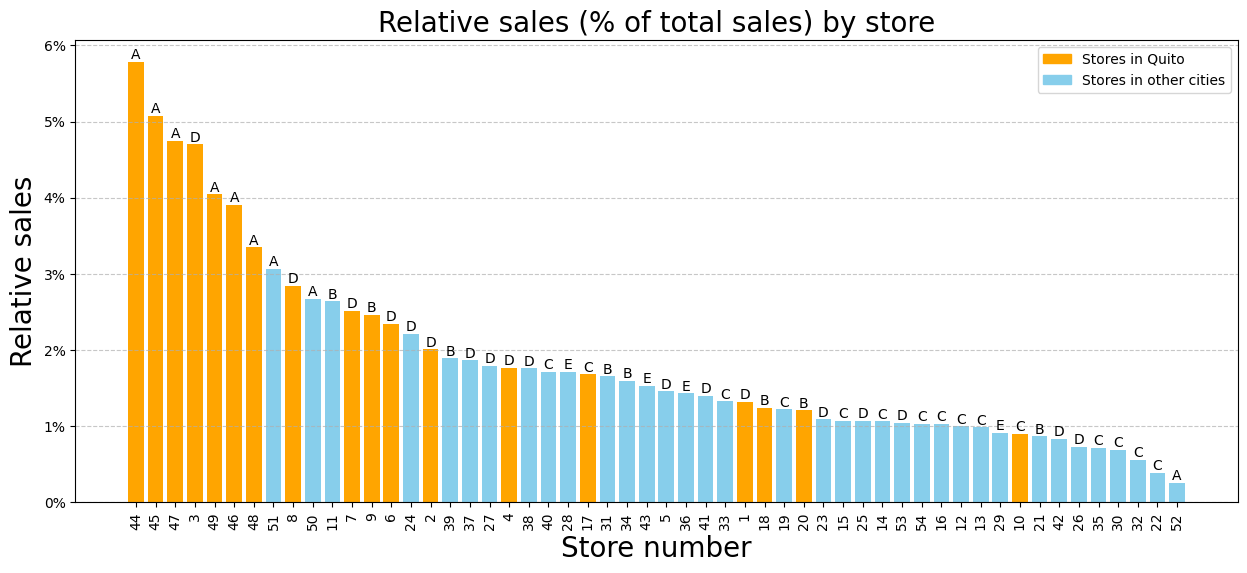

In [4]:
sales_by_store = df_orig.groupby('store_nbr').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    'type': 'first',  # Keep the first 'type' entry for each store_nbr
    'city': 'first'
}).reset_index()

# Get city info for each store
store_city = df_orig[['store_nbr', 'city']].drop_duplicates()

# Sort by 'unit_sales' descending
sales_by_store_sorted = sales_by_store.sort_values(by='unit_sales', ascending=False)

# Convert 'store_nbr' to categorical with explicit ordering
sales_by_store_sorted['store_nbr'] = pd.Categorical(
    sales_by_store_sorted['store_nbr'], categories=sales_by_store_sorted['store_nbr'], ordered=True)

# Calculate Relative sales
total_unit_sales = sales_by_store_sorted['unit_sales'].sum()
sales_by_store_sorted['relative sales'] = 100*sales_by_store_sorted['unit_sales'] / total_unit_sales

# Strip spaces from column names
sales_by_store_sorted.columns = sales_by_store_sorted.columns.str.strip()

# **DO NOT REASSIGN sales_by_store_sorted HERE!** Keep the processed version

# Set 'store_nbr' as the index to preserve order
sales_by_store_sorted.set_index('store_nbr', inplace=True)

# Example: sales_by_store_sorted contains 'store_nbr', 'unit_sales', and 'city'
highlight_city = 'Quito'
highlight_color = 'orange'
default_color = 'skyblue'


plt.figure(figsize=(15, 6))

# Create legend manually
quito_patch = mpatches.Patch(color=highlight_color, label="Stores in Quito")
other_cities_patch = mpatches.Patch(color=default_color, label="Stores in other cities")
plt.legend(handles=[quito_patch, other_cities_patch], loc="upper right", fontsize=10)

# Create a color list for each bar
bar_colors = sales_by_store_sorted['city'].apply(lambda c: highlight_color if c == highlight_city else default_color)

# **Use column name instead of index for clarity**
plt.bar(sales_by_store_sorted.index.astype(str), sales_by_store_sorted['relative sales'], color=bar_colors)

# Add labels from the 'type' column
for idx, value in enumerate(sales_by_store_sorted['relative sales']):
    plt.text(
        sales_by_store_sorted.index.astype(str)[idx],  # X position
        value,  # Y position
        sales_by_store_sorted['type'].iloc[idx],  # Label text
        ha='center', va='bottom')  # Centering and positioning
    
# Improve readability
plt.xticks(rotation=90)
plt.xlabel("Store number", fontsize=20)
plt.ylabel("Relative sales", fontsize=20)
plt.title("Relative sales (% of total sales) by store", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis labels to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.show()

## Group by Store and make a plot showing contribution to total sales

sales_by_store = df_orig.groupby('store_nbr').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    'type': 'first',  # Keep the first 'type' entry for each store_nbr
    'city': 'first'
}).reset_index()

# Get city info for each store
store_city = df_orig[['store_nbr', 'city']].drop_duplicates()

# Sort by 'unit_sales' descending
sales_by_store_sorted = sales_by_store.sort_values(by='unit_sales', ascending=False)

# Convert 'store_nbr' to categorical with explicit ordering
sales_by_store_sorted['store_nbr'] = pd.Categorical(
    sales_by_store_sorted['store_nbr'], categories=sales_by_store_sorted['store_nbr'], ordered=True
)

total_unit_sales = sales_by_store_sorted['unit_sales'].sum()
sales_by_store_sorted['proportion to total sales'] = sales_by_store_sorted['unit_sales'] / total_unit_sales
sales_by_store_sorted['accumulative proportion'] = sales_by_store_sorted['proportion to total sales'].cumsum()

# Strip spaces from column names
sales_by_store_sorted.columns = sales_by_store_sorted.columns.str.strip()

# **DO NOT REASSIGN sales_by_store_sorted HERE!** Keep the processed version

# Set 'store_nbr' as the index to preserve order
sales_by_store_sorted.set_index('store_nbr', inplace=True)

# Example: sales_by_store_sorted contains 'store_nbr', 'unit_sales', and 'city'
highlight_city = 'Quito'
highlight_color = 'orange'
default_color = 'skyblue'

import matplotlib.patches as mpatches



plt.figure(figsize=(15, 6))

# Create legend manually
quito_patch = mpatches.Patch(color=highlight_color, label="Stores in Quito")
other_cities_patch = mpatches.Patch(color=default_color, label="Stores in other cities")
plt.legend(handles=[quito_patch, other_cities_patch], loc="upper left")

# Create a color list for each bar
bar_colors = sales_by_store_sorted['city'].apply(lambda c: highlight_color if c == highlight_city else default_color)

# **Use column name instead of index for clarity**
plt.bar(sales_by_store_sorted.index.astype(str), sales_by_store_sorted['accumulative proportion'], color=bar_colors)

# Add labels from the 'type' column
for idx, value in enumerate(sales_by_store_sorted['accumulative proportion']):
    plt.text(
        sales_by_store_sorted.index.astype(str)[idx],  # X position
        value,  # Y position
        sales_by_store_sorted['type'].iloc[idx],  # Label text
        ha='center', va='bottom'  # Centering and positioning
    )

# Improve readability
plt.xticks(rotation=90)
plt.xlabel("Store Number")
plt.ylabel("Accumulated Proportion of Total Sales")
plt.title("Relative Cumulative Sales by Store")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()





##  Group sales by both year and store

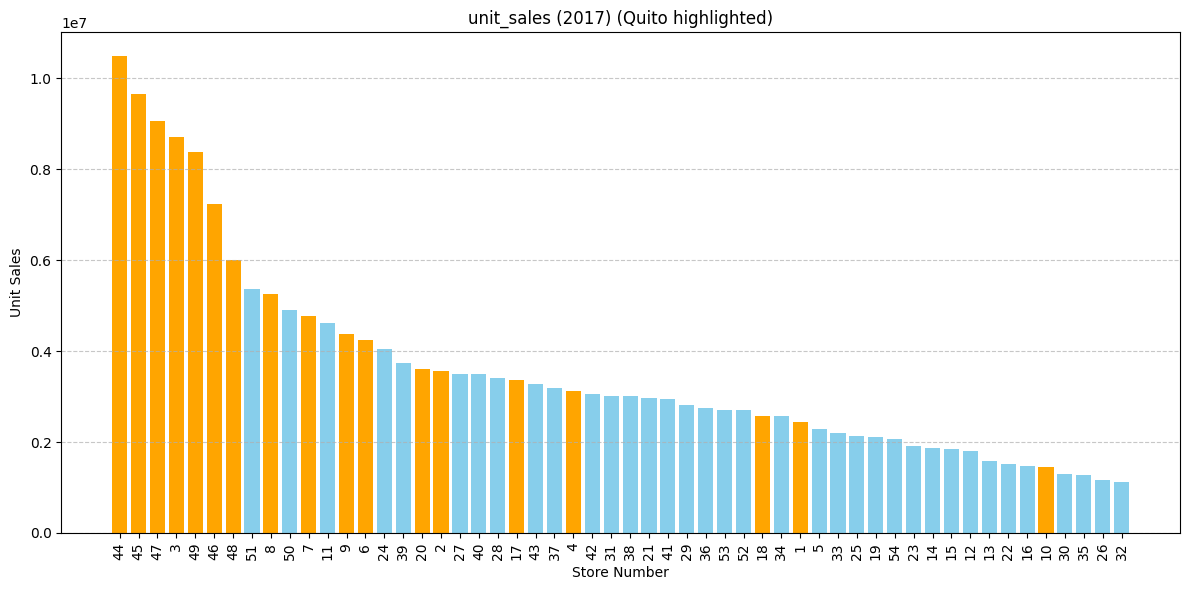

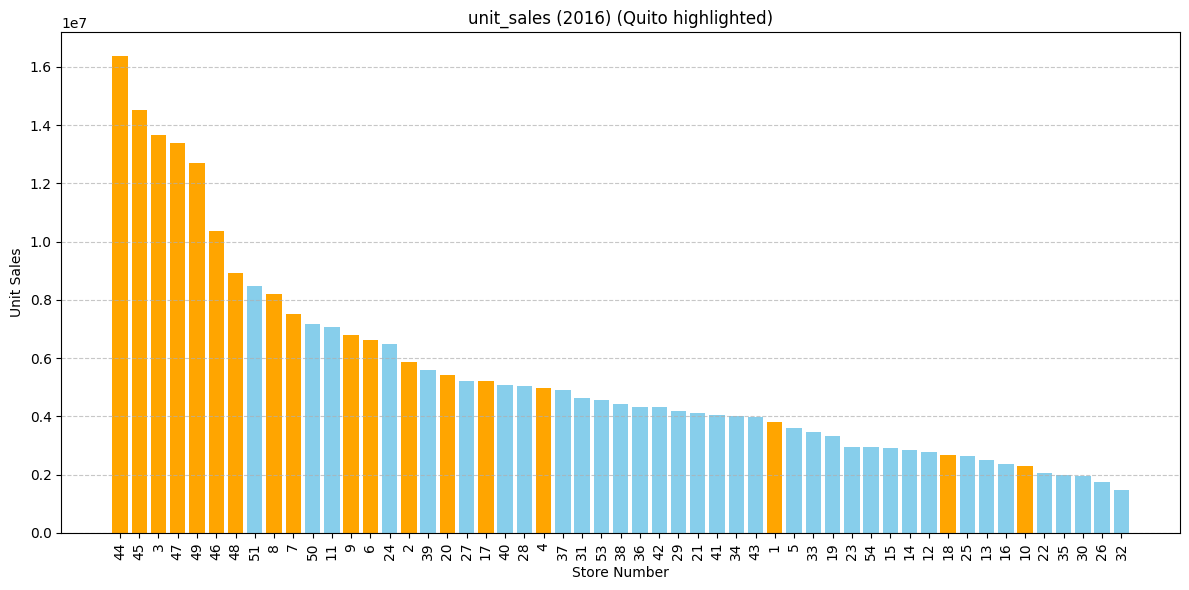

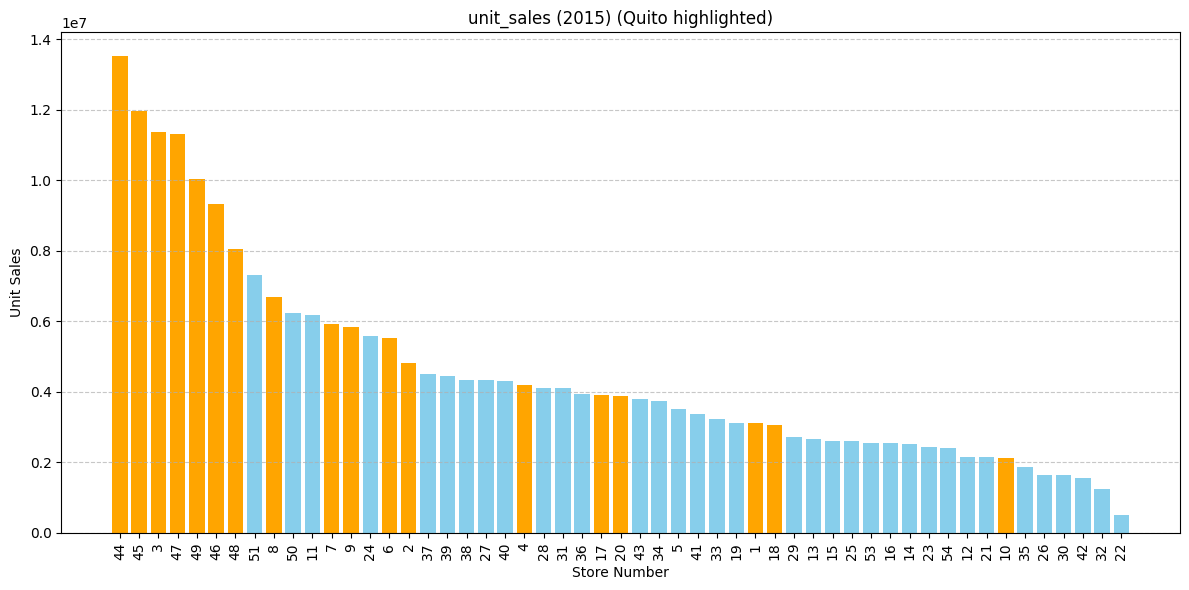

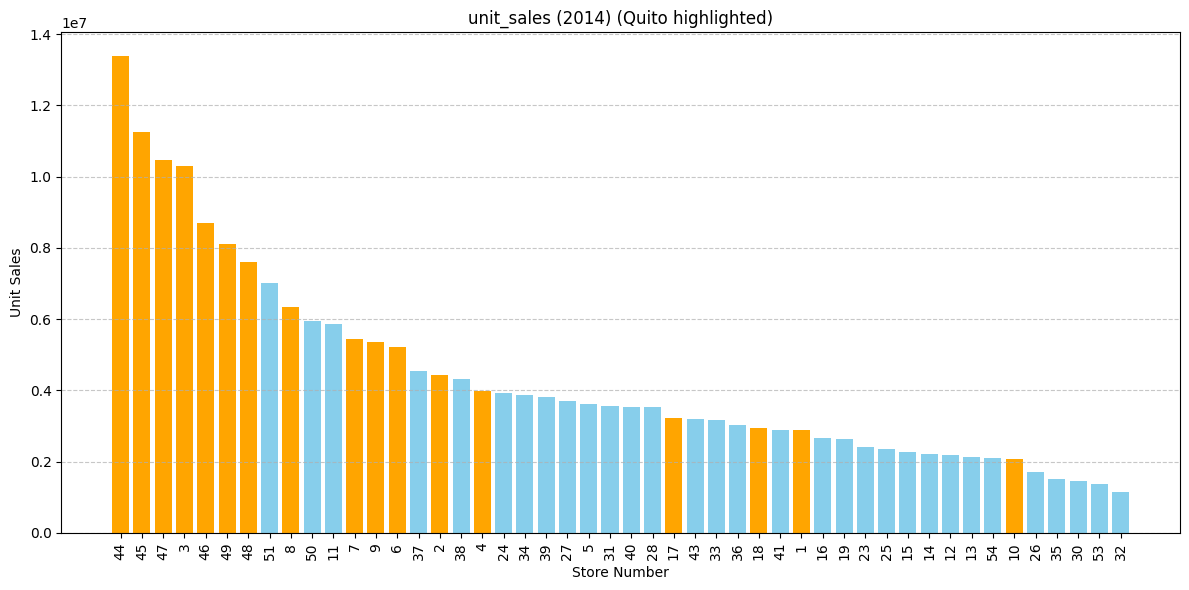

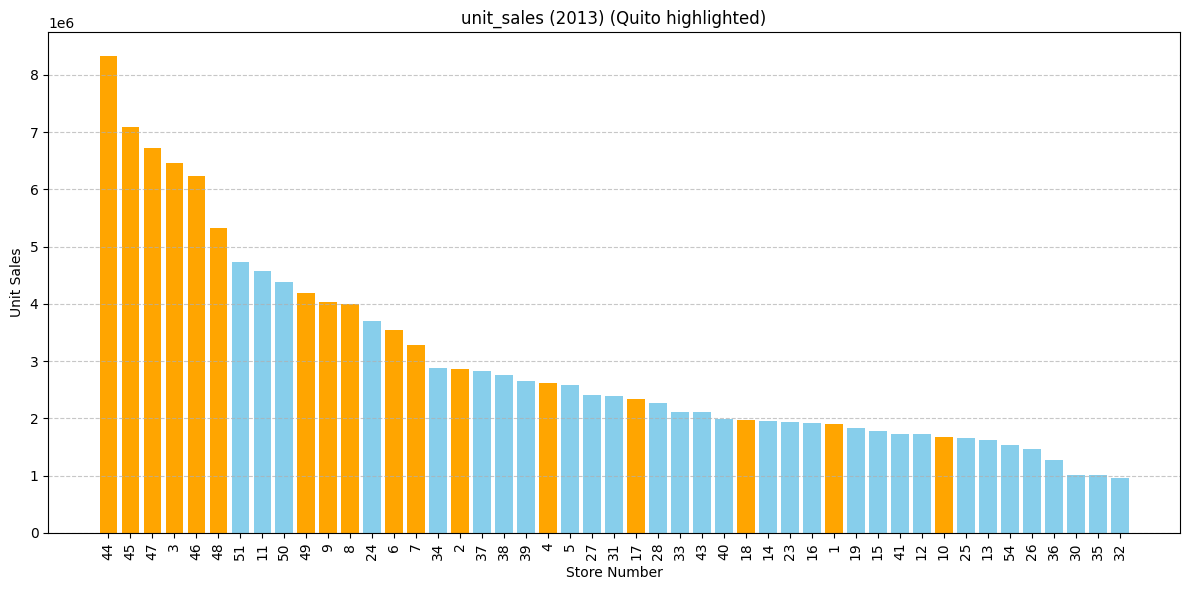

In [5]:
df_orig['month'] = df_orig['month'].astype(str)
df_orig['date'] = pd.to_datetime(df_orig['month']) + pd.to_timedelta(df_orig['day'] - 1, unit='d')

# Get city info for each store
store_city = df_orig[['store_nbr', 'city']].drop_duplicates()

# Group by store_nbr and sum the sales
df_orig_2017 = df_orig[df_orig['date'] > pd.to_datetime('2016-12-31')]
df_orig_2016 = df_orig[(df_orig['date'] > pd.to_datetime('2015-12-31')) & (df_orig['date'] <pd.to_datetime('2017-01-01'))]
df_orig_2015 = df_orig[(df_orig['date'] > pd.to_datetime('2014-12-31')) & (df_orig['date'] <pd.to_datetime('2016-01-01'))]
df_orig_2014 = df_orig[(df_orig['date'] > pd.to_datetime('2013-12-31')) & (df_orig['date'] <pd.to_datetime('2015-01-01'))]
df_orig_2013 = df_orig[df_orig['date'] < pd.to_datetime('2014-01-01')]


# List of yearly dataframes
yearly_dfs = {
    "2017": df_orig_2017,
    "2016": df_orig_2016,
    "2015": df_orig_2015,
    "2014": df_orig_2014,
    "2013": df_orig_2013
}

# Loop through each dataframe
for year, df in yearly_dfs.items():
    # Group by store_nbr and sum the sales
    sales_by_store = df.groupby('store_nbr')['unit_sales'].sum().reset_index()

    # Merge with sales_by_store
    sales_by_store = sales_by_store.merge(store_city, on='store_nbr', how='left')

    # Sort by 'unit_sales' descending
    sales_by_store_sorted = sales_by_store.sort_values(by='unit_sales', ascending=False)

    # Convert 'store_nbr' to categorical with explicit ordering
    sales_by_store_sorted['store_nbr'] = pd.Categorical(
        sales_by_store_sorted['store_nbr'], categories=sales_by_store_sorted['store_nbr'], ordered=True)

    # Calculate proportions
    total_unit_sales = sales_by_store_sorted['unit_sales'].sum()
    sales_by_store_sorted['proportion to total sales'] = sales_by_store_sorted['unit_sales'] / total_unit_sales
    
    # Strip spaces from column names
    sales_by_store_sorted.columns = sales_by_store_sorted.columns.str.strip()

    # Set 'store_nbr' as the index to preserve order
    sales_by_store_sorted.set_index('store_nbr', inplace=True)

    # Example: sales_by_store_sorted contains 'store_nbr', 'unit_sales', and 'city'
    highlight_city = 'Quito'
    highlight_color = 'orange'
    default_color = 'skyblue'

    # Create a color list for each bar
    bar_colors = sales_by_store_sorted['city'].apply(
    lambda c: highlight_color if c == highlight_city else default_color)

    plt.figure(figsize=(12, 6))
    plt.bar(sales_by_store_sorted.index.astype(str), sales_by_store_sorted['unit_sales'], color=bar_colors)
    plt.xticks(rotation=90)
    plt.xlabel("Store Number")
    plt.xticks(range(len(sales_by_store_sorted.index)), sales_by_store_sorted.index.astype(str))
    plt.ylabel("Unit Sales")
    plt.title(f"unit_sales ({year}) (Quito highlighted)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


    

## Group by family and sum unit_sales

C:\Users\jasmi\AppData\Local\Temp\ipykernel_24580\949762709.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_family = df_orig.groupby('family').agg({


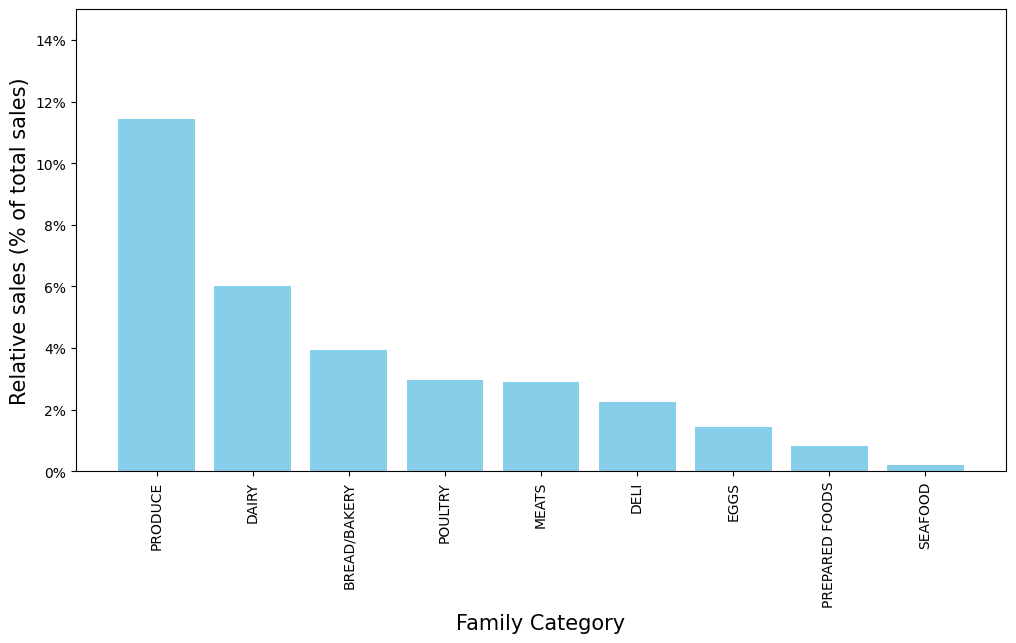

In [6]:
# Group by family and sum the sales
sales_by_family = df_orig.groupby('family').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    'perishable': 'first',  # Keep the first 'perishable' entry for each store_nbr
    }).reset_index()


# Sort by 'unit_sales' descending
sales_by_family_sorted = sales_by_family.sort_values(by='unit_sales', ascending=False)
total_unit_sales = sales_by_family_sorted['unit_sales'].sum()

sales_by_family_sorted['proportion to total sales'] =100*sales_by_family_sorted['unit_sales']/total_unit_sales

# Define colors
# default_color = 'skyblue'
# highlight_color = 'red'
highlight_color = 'skyblue'

# Define the labels to highlight
highlight_labels = ['BREAD/BAKERY', 'DELI', 'DAIRY', 'EGGS', 'PREPARED FOODS', 'SEAFOOD', 'MEATS', 'POULTRY', 'PRODUCE']

# Assign colors based on whether 'family' is in highlight_labels
bar_colors = [highlight_color if family in highlight_labels else default_color for family in sales_by_family_sorted['family']]

sales_by_family_sorted = sales_by_family_sorted[sales_by_family_sorted['perishable']== 1]

plt.figure(figsize=(12, 6))
plt.bar(sales_by_family_sorted['family'], sales_by_family_sorted['proportion to total sales'], color=bar_colors)

# Improve readability
plt.xticks(rotation=90)  # Rotate family labels for better visibility

# Modify label colors selectively
plt.xlabel("Family Category", fontsize=15)
plt.ylim(0, 15)
plt.ylabel("Relative sales (% of total sales)", fontsize=15)

# Format y-axis labels to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# **Add a legend to explain colors**
# import matplotlib.patches as mpatches
# highlight_patch = mpatches.Patch(color=highlight_color, label="Perishables")
# other_patch = mpatches.Patch(color=default_color, label="Non perishables")
# plt.legend(handles=[highlight_patch, other_patch], loc="upper right")

# Show the plot
plt.show()

## Group by state and sum unit_sales

# Group by state and sum the sales
sales_by_state = df_orig.groupby('state')['unit_sales'].sum().reset_index()

# Sort by 'unit_sales' descending
sales_by_state_sorted = sales_by_state.sort_values(by='unit_sales', ascending=False)
total_unit_sales = sales_by_state_sorted['unit_sales'].sum()

sales_by_state_sorted['proportion to to total sales'] = sales_by_state_sorted['unit_sales']/total_unit_sales
sales_by_state_sorted['accumulative proportion'] = sales_by_state_sorted['proportion to to total sales'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(sales_by_state_sorted['state'], sales_by_state_sorted['accumulative proportion'], marker='o', linestyle='-')

plt.xlabel("State")
plt.xticks(rotation=90)
plt.ylim(0, 1.2)
plt.ylabel("Relative cumulative sales")
plt.title("Relative cumulative sales by state")
plt.grid(True)

# Show the plot
plt.show()

## Group by type and sum unit_sales

C:\Users\jasmi\AppData\Local\Temp\ipykernel_24580\1973286512.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_type = df_orig.groupby('type')['unit_sales'].sum().reset_index()


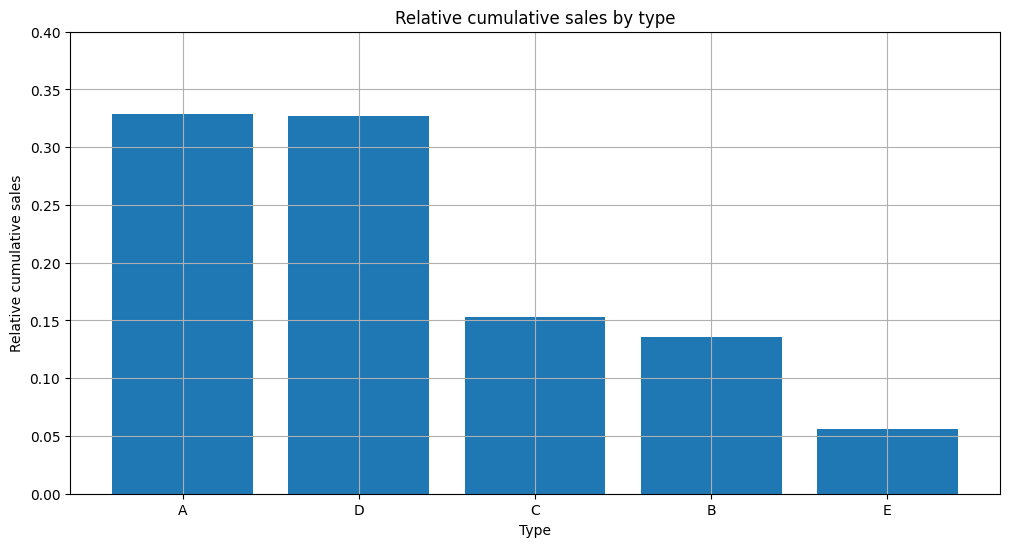

The relative sales of A-type stores is 0    0.328838
Name: proportion to total sales, dtype: float32
The relative sales of B-type stores is 1    0.13529
Name: proportion to total sales, dtype: float32
The relative sales of C-type stores is 2    0.15316
Name: proportion to total sales, dtype: float32
The relative sales of D-type stores is 3    0.326993
Name: proportion to total sales, dtype: float32


In [10]:
# Group by type and sum the sales
sales_by_type = df_orig.groupby('type')['unit_sales'].sum().reset_index()

# Sort by 'unit_sales' descending
sales_by_type_sorted = sales_by_type.sort_values(by='unit_sales', ascending=False)
total_unit_sales = sales_by_type_sorted['unit_sales'].sum()

sales_by_type_sorted['proportion to total sales'] = sales_by_type_sorted['unit_sales']/total_unit_sales
sales_by_type_sorted['accumulative proportion'] = sales_by_type_sorted['proportion to total sales'].cumsum()

plt.figure(figsize=(12, 6))
plt.bar(sales_by_type_sorted['type'], sales_by_type_sorted['proportion to total sales'])

plt.xlabel("Type")
plt.ylim(0, 0.4)
plt.ylabel("Relative cumulative sales")
plt.title("Relative cumulative sales by type")
plt.grid(True)

# Show the plot
plt.show()


print(f'The relative sales of A-type stores is {sales_by_type_sorted["proportion to total sales"][sales_by_type_sorted["type"] == "A"]}')
print(f'The relative sales of B-type stores is {sales_by_type_sorted["proportion to total sales"][sales_by_type_sorted["type"] == "B"]}')
print(f'The relative sales of C-type stores is {sales_by_type_sorted["proportion to total sales"][sales_by_type_sorted["type"] == "C"]}')
print(f'The relative sales of D-type stores is {sales_by_type_sorted["proportion to total sales"][sales_by_type_sorted["type"] == "D"]}')

## Group by cluster and sum unit_sales

In [ ]:
# Group by cluster and sum the sales
sales_by_cluster = df_orig.groupby('cluster')['unit_sales'].sum().reset_index()

# Sort by 'unit_sales' descending
sales_by_cluster_sorted = sales_by_cluster.sort_values(by='unit_sales', ascending=False)
total_unit_sales = sales_by_cluster_sorted['unit_sales'].sum()

sales_by_cluster_sorted['proportion to to total sales'] = sales_by_cluster_sorted['unit_sales']/total_unit_sales
sales_by_cluster_sorted['accumulative proportion'] = sales_by_cluster_sorted['proportion to to total sales'].cumsum()

# Strip spaces from column names
sales_by_cluster_sorted.columns = sales_by_cluster_sorted.columns.str.strip()

# Set 'cluster' as the index to preserve order
sales_by_cluster_sorted.set_index('cluster', inplace=True)

plt.figure(figsize=(12, 6))

# **Use column name instead of index for clarity**
plt.bar(sales_by_cluster_sorted.index.astype(str), sales_by_cluster_sorted['accumulative proportion'], color='skyblue')

# Improve readability
plt.xlabel("Cluster")
plt.ylabel("Relative Cumulative Sales")
plt.title("Relative Cumulative Sales by Cluster")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


## Scope the first 16 rows (or 99% of the sales) of the df_70pcnt_scoped dataframe

# Ensure the index is sequential
sales_by_family_sorted.reset_index(drop=True, inplace=True)

# Select the first 10 rows of specific columns
top_10_families = sales_by_family_sorted.loc[0:9, ['family']]
print(top_10_families)

df_double_scope = df_orig[df_orig['family'].isin(['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE','DELI', 'EGGS', 'FROZEN FOODS', 'HOME CARE', 'PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'])]
print(df_double_scope.head(10))
print(df_double_scope.head(-10))

## Grafiek met sales per familie in functie van de tijd

grouped_by_family_df = df_orig.groupby(['family', 'month'])['unit_sales'].sum().reset_index()
top_family_df = grouped_by_family_df[grouped_by_family_df['family'].isin(['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY'])]
top_family_df['month'] = pd.to_datetime(top_family_df['month'], format='%Y-%m')

subtop_family_df = grouped_by_family_df[grouped_by_family_df['family'].isin(['BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'])]
subtop_family_df['month'] = pd.to_datetime(subtop_family_df['month'], format='%Y-%m')

top11_16_family_df = grouped_by_family_df[grouped_by_family_df['family'].isin(['EGGS', 'FROZEN FOODS', 'HOME CARE', 'PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'])]
top11_16_family_df['month'] = pd.to_datetime(top11_16_family_df['month'], format='%Y-%m')


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))


sns.lineplot(data=top_family_df, x='month', y='unit_sales', hue='family', hue_order=['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY'], ax=ax1)
ax1.set_title('Top Families (#1-5)')

sns.lineplot(data=subtop_family_df, x='month', y='unit_sales', hue='family', hue_order=['BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'], ax=ax2)
ax2.set_title('Subtop Families (#6-10)')

sns.lineplot(data=top11_16_family_df, x='month', y='unit_sales', hue='family', hue_order=['EGGS', 'FROZEN FOODS', 'HOME CARE', 'PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'], ax=ax3)
ax3.set_title('Subtop Families (#11-16)')


plt.tight_layout()
plt.show()


## Create a new date column including the days

In [26]:

df_orig['month'] = df_orig['month'].astype(str)

df_orig['date'] = pd.to_datetime(df_orig['month']) + pd.to_timedelta(df_orig['day'] - 1, unit='d')
print(df_orig.head(10))
print(df_orig.head(-10))

   id  store_nbr  item_nbr  unit_sales onpromotion  day    month  \
0   0         25  103665.0         7.0        None    1  2013-01   
1   1         25  105574.0         1.0        None    1  2013-01   
2   2         25  105575.0         2.0        None    1  2013-01   
3   3         25  108079.0         1.0        None    1  2013-01   
4   4         25  108701.0         1.0        None    1  2013-01   
5   5         25  108786.0         3.0        None    1  2013-01   
6   6         25  108797.0         1.0        None    1  2013-01   
7   7         25  108952.0         1.0        None    1  2013-01   
8   8         25  111397.0        13.0        None    1  2013-01   
9   9         25  114790.0         3.0        None    1  2013-01   

         family  class  perishable     city        state type  cluster  \
0  BREAD/BAKERY   2712           1  Salinas  Santa Elena    D        1   
1     GROCERY I   1045           0  Salinas  Santa Elena    D        1   
2     GROCERY I   1045       

## Make a lineplot for produce in function of time and on a weekly basis

grouped_by_family_df = df_orig.groupby(['family', 'date'])['unit_sales'].sum().reset_index()

weekly_df = grouped_by_family_df.groupby(['family', pd.Grouper(key='date', freq='W')]).sum().reset_index()

top2_df = weekly_df[weekly_df['family'].isin(['PRODUCE','DAIRY'])]
top5_df = weekly_df[weekly_df['family'].isin(['PRODUCE','DAIRY', 'BREAD/BAKERY','POULTRY', 'MEATS'])]
top6_df = weekly_df[weekly_df['family'].isin(['CLEANING', 'DAIRY', 'BREAD/BAKERY'])]
top10_df = weekly_df[weekly_df['family'].isin(['POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'])]
top13_df = weekly_df[weekly_df['family'].isin(['EGGS', 'FROZEN FOODS', 'HOME CARE'])]
top16_df = weekly_df[weekly_df['family'].isin(['PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'])]

 
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.ylabel("Million unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
sns.lineplot(data=top2_df, x='date', y='unit_sales', hue='family', hue_order=['PRODUCE','DAIRY'], ax=ax1)

#fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12))
#sns.lineplot(data=top6_df, x='date', y='unit_sales', hue='family', hue_order=['CLEANING', 'DAIRY', 'BREAD/BAKERY'], ax=ax2)
#ax2.set_title('Subtop Families (#4-6)')

#sns.lineplot(data=top10_df, x='date', y='unit_sales', hue='family', hue_order=['POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'], ax=ax3)
#ax3.set_title('Subtop Families (#7-10)')

#sns.lineplot(data=top13_df, x='date', y='unit_sales', hue='family', hue_order=['EGGS', 'FROZEN FOODS', 'HOME CARE'], ax=ax4)
#ax3.set_title('Subtop Families (#11-13)')

#sns.lineplot(data=top16_df, x='date', y='unit_sales', hue='family', hue_order=['PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'], ax=ax5)
#ax3.set_title('Subtop Families (#14-16)')

plt.tight_layout()
plt.show()
 

## Find the missing values for each store

# Find the number of missing values for each column
df_grocery_I = df_double_scope[df_double_scope['family'] == 'GROCERY I']
print(df_grocery_I.head(10))

missing_values_df = pd.DataFrame(df_grocery_I.isnull().sum())
missing_values_df.columns = ['number of missing values']
missing_values_df['datatype']=df_grocery_I.dtypes
missing_values_df['missing frequency (%)']=100 * missing_values_df['number of missing values']/len(df_grocery_I)

# Make a new dataframes having only numerical variables
missing_values_df_num = missing_values_df[missing_values_df['datatype']!='object']

#  Remove columns that do not have missing values
missing_values_df_num = missing_values_df_num[missing_values_df_num['number of missing values']!=0]

print(f"The number of missing values for unit_sales is {missing_values_df.loc['unit_sales', 'number of missing values']}")
print(missing_values_df_num)
print(f"The number of columns with numerical variables and missing values is {missing_values_df_num.shape[0]}")



## missing values for PRODUCE family

# Find the number of missing values for each column
df_produce = df_double_scope[df_double_scope['family'] == 'PRODUCE']
print(df_produce.head(20))

missing_values_df = pd.DataFrame(df_produce.isnull().sum())
missing_values_df.columns = ['number of missing values']
missing_values_df['datatype']=df_produce.dtypes
missing_values_df['missing frequency (%)']=100 * missing_values_df['number of missing values']/len(df_produce)

# Make a new dataframes having only numerical variables
missing_values_df_num = missing_values_df[missing_values_df['datatype']!='object']

#  Remove columns that do not have missing values
missing_values_df_num = missing_values_df_num[missing_values_df_num['number of missing values']!=0]

print(f"The number of missing values for unit_sales is {missing_values_df.loc['unit_sales', 'number of missing values']}")
print(missing_values_df_num)
print(f"The number of columns with numerical variables and missing values is {missing_values_df_num.shape[0]}")

## Make a plot for PRODUCE family products only


# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df = df_double_scope[(df_double_scope['family'] == 'PRODUCE') & (df_double_scope['date'] < '2014-01-01')]


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12))

# Create the seaborn lineplot
sns.lineplot(data=filtered_df, x='date', y='unit_sales', ax=ax1)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df2 = df_double_scope[(df_double_scope['family'] == 'PRODUCE') & (df_double_scope['date'] < '2015-01-01') & (df_double_scope['date'] > '2013-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df2, x='date', y='unit_sales', ax=ax2)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df3 = df_double_scope[(df_double_scope['family'] == 'PRODUCE') & (df_double_scope['date'] < '2016-01-01') & (df_double_scope['date'] > '2014-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df3, x='date', y='unit_sales', ax=ax3)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df4 = df_double_scope[(df_double_scope['family'] == 'PRODUCE') & (df_double_scope['date'] < '2017-01-01') & (df_double_scope['date'] > '2015-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df4, x='date', y='unit_sales', ax=ax4)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df5 = df_double_scope[(df_double_scope['family'] == 'PRODUCE') & (df_double_scope['date'] > '2016-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df5, x='date', y='unit_sales', ax=ax5)
plt.xlabel("Date")



## Plot 2014 unit_sales broken down over the top 4 most selling stores

df_top_4 = df_double_scope[df_double_scope['store_nbr'].isin([44, 45, 47, 3])]

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df = df_top_4[(df_top_4['family'] == 'PRODUCE') & (df_top_4['date'] < '2014-01-01')]


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12))

# Create the seaborn lineplot
sns.lineplot(data=filtered_df, x='date', y='unit_sales', hue='store_nbr', hue_order=[44, 45, 47, 3], ax=ax1)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df2 = df_top_4[(df_top_4['family'] == 'PRODUCE') & (df_top_4['date'] < '2015-01-01') & (df_top_4['date'] > '2013-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df2, x='date', y='unit_sales', hue='store_nbr', hue_order=[44, 45, 47, 3], ax=ax2)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df3 = df_top_4[(df_top_4['family'] == 'PRODUCE') & (df_top_4['date'] < '2016-01-01') & (df_top_4['date'] > '2014-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df3, x='date', y='unit_sales', hue='store_nbr', hue_order=[44, 45, 47, 3], ax=ax3)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df4 = df_top_4[(df_top_4['family'] == 'PRODUCE') & (df_top_4['date'] < '2017-01-01') & (df_top_4['date'] > '2015-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df4, x='date', y='unit_sales', hue='store_nbr', hue_order=[44, 45, 47, 3], ax=ax4)

# Filter the DataFrame for 'family'='produce' and date before March 2014
filtered_df5 = df_top_4[(df_top_4['family'] == 'PRODUCE') & (df_top_4['date'] > '2016-12-31')]

# Create the seaborn lineplot
sns.lineplot(data=filtered_df5, x='date', y='unit_sales', hue='store_nbr', hue_order=[44, 45, 47, 3], ax=ax5)
plt.xlabel("Date")


## Give tables for produce May 2014 and September 2014 for store_nbr 44

In [ ]:
# Produce dataframe for store_nbr 43 in May
produce_df = df_double_scope[df_double_scope['family'] == 'PRODUCE']
produce_df_44 = produce_df[produce_df['store_nbr'] == 44]
produce_df_44['date'] = pd.to_datetime(produce_df_44['date'])

# Produce dataframe for store_nbr 43 in May and September
produce_df_44_may = produce_df_44[(produce_df_44['date'] < '2014-05-31') & (produce_df_44['date'] > '2014-05-01')]
produce_df_44_sep = produce_df_44[(produce_df_44['date'] < '2014-09-30') & (produce_df_44['date'] > '2014-09-01')]

print(f"Number of rows in the produce store_nbr 43 May dataframe is: {produce_df_44_may.shape[0]}")
print(f"Number of rows in the produce store_nbr 43 September dataframe is: {produce_df_44_sep.shape[0]}")

print(f"Number of unique item_nbr values in the store_nbr 43 May dataframe is: {produce_df_44_may['item_nbr'].nunique()}")
print(f"Number of unique item_nbr values in the store_nbr 43 September dataframe is: {produce_df_44_sep['item_nbr'].nunique()}")



print(produce_df_44_may.head(15))
print(produce_df_44_sep.head(15))



## Now the same for all stores

In [ ]:
# Produce dataframe for store_nbr 43 in May
produce_df = df_double_scope[df_double_scope['family'] == 'PRODUCE']
produce_df['date'] = pd.to_datetime(produce_df['date'])

# Produce dataframe for store_nbr 43 in May and September
produce_df_may = produce_df[(produce_df['date'] < '2014-05-31') & (produce_df['date'] > '2014-05-01')]
produce_df_sep = produce_df[(produce_df['date'] < '2014-09-30') & (produce_df['date'] > '2014-09-01')]

print(f"Number of rows in the produce May dataframe (all scoped stores) is: {produce_df_may.shape[0]}")
print(f"Number of rows in the produce September dataframe (all scoped stores) is: {produce_df_sep.shape[0]}")

print(f"Number of unique item_nbr values in the May dataframe (all scoped stores) is: {produce_df_may['item_nbr'].nunique()}")
print(f"Number of unique item_nbr values in the September dataframe (all scoped stores) is: {produce_df_sep['item_nbr'].nunique()}")

print(produce_df_may.head(15))
print(produce_df_sep.head(15))

# Group GROCERY I, BEVERAGES and PRODUCE by store_nbr




df_grouped_by_store_nbr = df_double_scope.groupby(['family', 'store_nbr'])['unit_sales'].sum().reset_index()

# Filter the df_grouped_by_store_nbr DataFrame for GROCERY I , PRODUCE or BEVERAGES
df_grouped_by_store_nbr_grocery_I = df_grouped_by_store_nbr[(df_grouped_by_store_nbr['family'] == 'GROCERY I')]
df_grouped_by_store_nbr_beverages = df_grouped_by_store_nbr[(df_grouped_by_store_nbr['family'] == 'BEVERAGES')]
df_grouped_by_store_nbr_produce = df_grouped_by_store_nbr[(df_grouped_by_store_nbr['family'] == 'PRODUCE')]

print(df_grouped_by_store_nbr_grocery_I.head())
print(df_grouped_by_store_nbr_beverages.head())
print(df_grouped_by_store_nbr_produce.head())

print(df_grouped_by_store_nbr_grocery_I["store_nbr"].nunique())  
print(sorted(df_grouped_by_store_nbr_grocery_I["store_nbr"].unique()))

sns.barplot(data=df_grouped_by_store_nbr_grocery_I, x="store_nbr", y="unit_sales")
plt.title("grocery I")
plt.show()

sns.barplot(data=df_grouped_by_store_nbr_beverages, x="store_nbr", y="unit_sales")
plt.title("beverages")
plt.show()

sns.barplot(data=df_grouped_by_store_nbr_produce, x="store_nbr", y="unit_sales")
plt.title("produce")
plt.show()




## Check correlation between PRODUCE and BEVERAGES family broken down over all stores

# Create a correlation dictionary
correlations = {}

# Iterate over each store
for store_nbr in df_double_scope['store_nbr'].unique():
    store_data = df_double_scope[df_double_scope['store_nbr'] == store_nbr]
    
    # Pivot to create time series for each family
    sales_pivot = store_data.pivot_table(index='date', columns='family', values='unit_sales', aggfunc='sum')
    
    # Check if both families exist for correlation computation
    if 'PRODUCE' in sales_pivot.columns and 'BEVERAGES' in sales_pivot.columns:
        correlation = sales_pivot['PRODUCE'].corr(sales_pivot['BEVERAGES'])
        correlations[store_nbr] = correlation

    # Plot sales trends
    plt.figure(figsize=(10, 5))
    plt.plot(sales_pivot.index, sales_pivot['PRODUCE'], label="PRODUCE family Sales", marker='o')
    plt.plot(sales_pivot.index, sales_pivot['BEVERAGES'], label="BEVERAGES family Sales", marker='s')
    plt.title(f'Sales Trends in Store {store_nbr}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid()
    plt.show()

# Display correlation results per store
print("Correlation between PRODUCE family and BEVERAGES family sales per store:")
print(correlations)


## Calculate correlation cooefficients for all families and all stores

# Create a correlation dictionary
correlations = {}

# Define the list of families to include
selected_families = ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY', 'BREAD/BAKERY', 'POULTRY', 'MEATS', 'PERSONAL CARE','DELI', 'EGGS', 'FROZEN FOODS', 'HOME CARE', 'PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD']

# Iterate over each store
for store_nbr in df_double_scope['store_nbr'].unique():
    store_data = df_double_scope[df_double_scope['store_nbr'] == store_nbr]
      
    # Pivot to create time series for each family
    ales_pivot = store_data.pivot_table(index='date', columns='family', values='unit_sales', aggfunc='sum')

    # Explicitly filter columns after pivoting
    sales_pivot = sales_pivot[selected_families]  # Keep only selected families

    # Compute correlation matrix
    correlation_matrix = sales_pivot.corr()

    # Store correlation matrix for each store
    correlations[store_nbr] = correlation_matrix

    # 📊 Print correlation matrix in a clean format
    print(f"\nCorrelation matrix for Store {store_nbr}:")
    print(correlation_matrix)
    # Clean table format
    print("-" * 50)

    # 🔥 Heatmap visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(f"Sales Correlation Heatmap - Store {store_nbr}")
    plt.show()


## Find missing family, store_nbr, sales, date combinations

# Assuming your dataframe is named df
all_dates = pd.date_range(start="2013-01-02", end="2017-08-15")  # All possible dates
stores = df_double_scope["store_nbr"].unique()  # Unique store numbers
families = df_double_scope["family"].unique()  # Unique product families

# Generate all possible (date, store_nbr, family) combinations
full_combinations = pd.DataFrame(product(all_dates, stores, families), columns=["date", "store_nbr", "family"])

# Merge with actual data
chunk_size = 1000000  # Adjust based on system capabilities
chunks = [df_double_scope[i:i+chunk_size] for i in range(0, len(df_double_scope), chunk_size)]
merged_chunks = [full_combinations.merge(chunk, on=["date", "store_nbr", "family"], how="left") for chunk in chunks]

# Concatenate results
merged_df = pd.concat(merged_chunks, ignore_index=True)

#  Merge with actual data
# merged_df = full_combinations.merge(df_double_scope, on=["date", "store_nbr", "family"], how="left")

# Find missing entries (where 'unit_sales' is NaN)
missing_entries = merged_df[merged_df["unit_sales"].isna()]

# Display missing combinations
print(missing_entries)


## Count the missing unit_sales for each store_nbr and for each family

missing_by_store = missing_entries.groupby("store_nbr")["unit_sales"].apply(lambda x: x.isna().sum()).reset_index()
missing_by_store.columns = ["Store Number", "Missing unit_sales Count"]
print(missing_by_store)

missing_by_family = missing_entries.groupby("family")["unit_sales"].apply(lambda x: x.isna().sum()).reset_index()
missing_by_family.columns = ["Product Family", "Missing unit_sales Count"]
print(missing_by_family)




## print all perishable family values

In [39]:
# Filtering for perishable items (perishable == 1)
perishable_families = df_orig[df_orig['perishable'] == 1]['family'].unique()

# Printing the list of perishable family values
print("Perishable Family Values:")
print(perishable_families)

# Print the length of the Series
print("Length of the perishable_families Series:", len(perishable_families))



Perishable Family Values:
['BREAD/BAKERY', 'DELI', 'DAIRY', 'EGGS', 'POULTRY', 'PREPARED FOODS', 'MEATS', 'SEAFOOD', 'PRODUCE']
Categories (33, object): ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', ..., 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']
Length of the perishable_families Series: 9
